Importing necessary libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.preprocessing import LabelEncoder

Reading data:

In [2]:
df_raw = pd.read_csv('Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Understanding data:

In [3]:
df = df_raw.copy()

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [8]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [9]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [12]:
df.drop(['customerID'], axis=1, inplace=True)

In [13]:
df['MultipleLines'].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [14]:
df = df.replace(
    to_replace = r'^No\s.*',
    value = 'No',
    regex = True
)

In [15]:
df[df['TotalCharges'].str.strip() == '']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No,No,No,No,No,No,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No,No,No,No,No,No,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No,No,No,No,No,No,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No,No,No,No,No,No,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No,No,No,No,No,No,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No,No,No,No,No,No,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [16]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [17]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [18]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


## EDA

In [20]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({
    0: 'No',
    1: 'Yes'
})

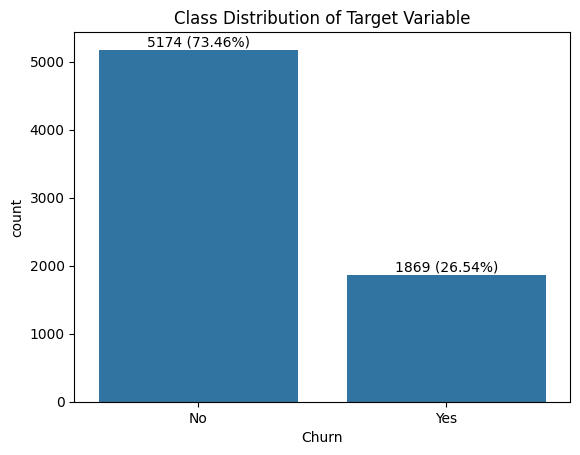

In [21]:
ax = sns.barplot(df['Churn'].value_counts())
plt.title('Class Distribution of Target Variable')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())} ({round(p.get_height() / len(df) * 100, 2)}%)',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

A significant class imbalance can be observed in the target variable `Churn`, where **73.46%** of customers belong to the "No" class and **26.54%** belong to the "Yes" class.

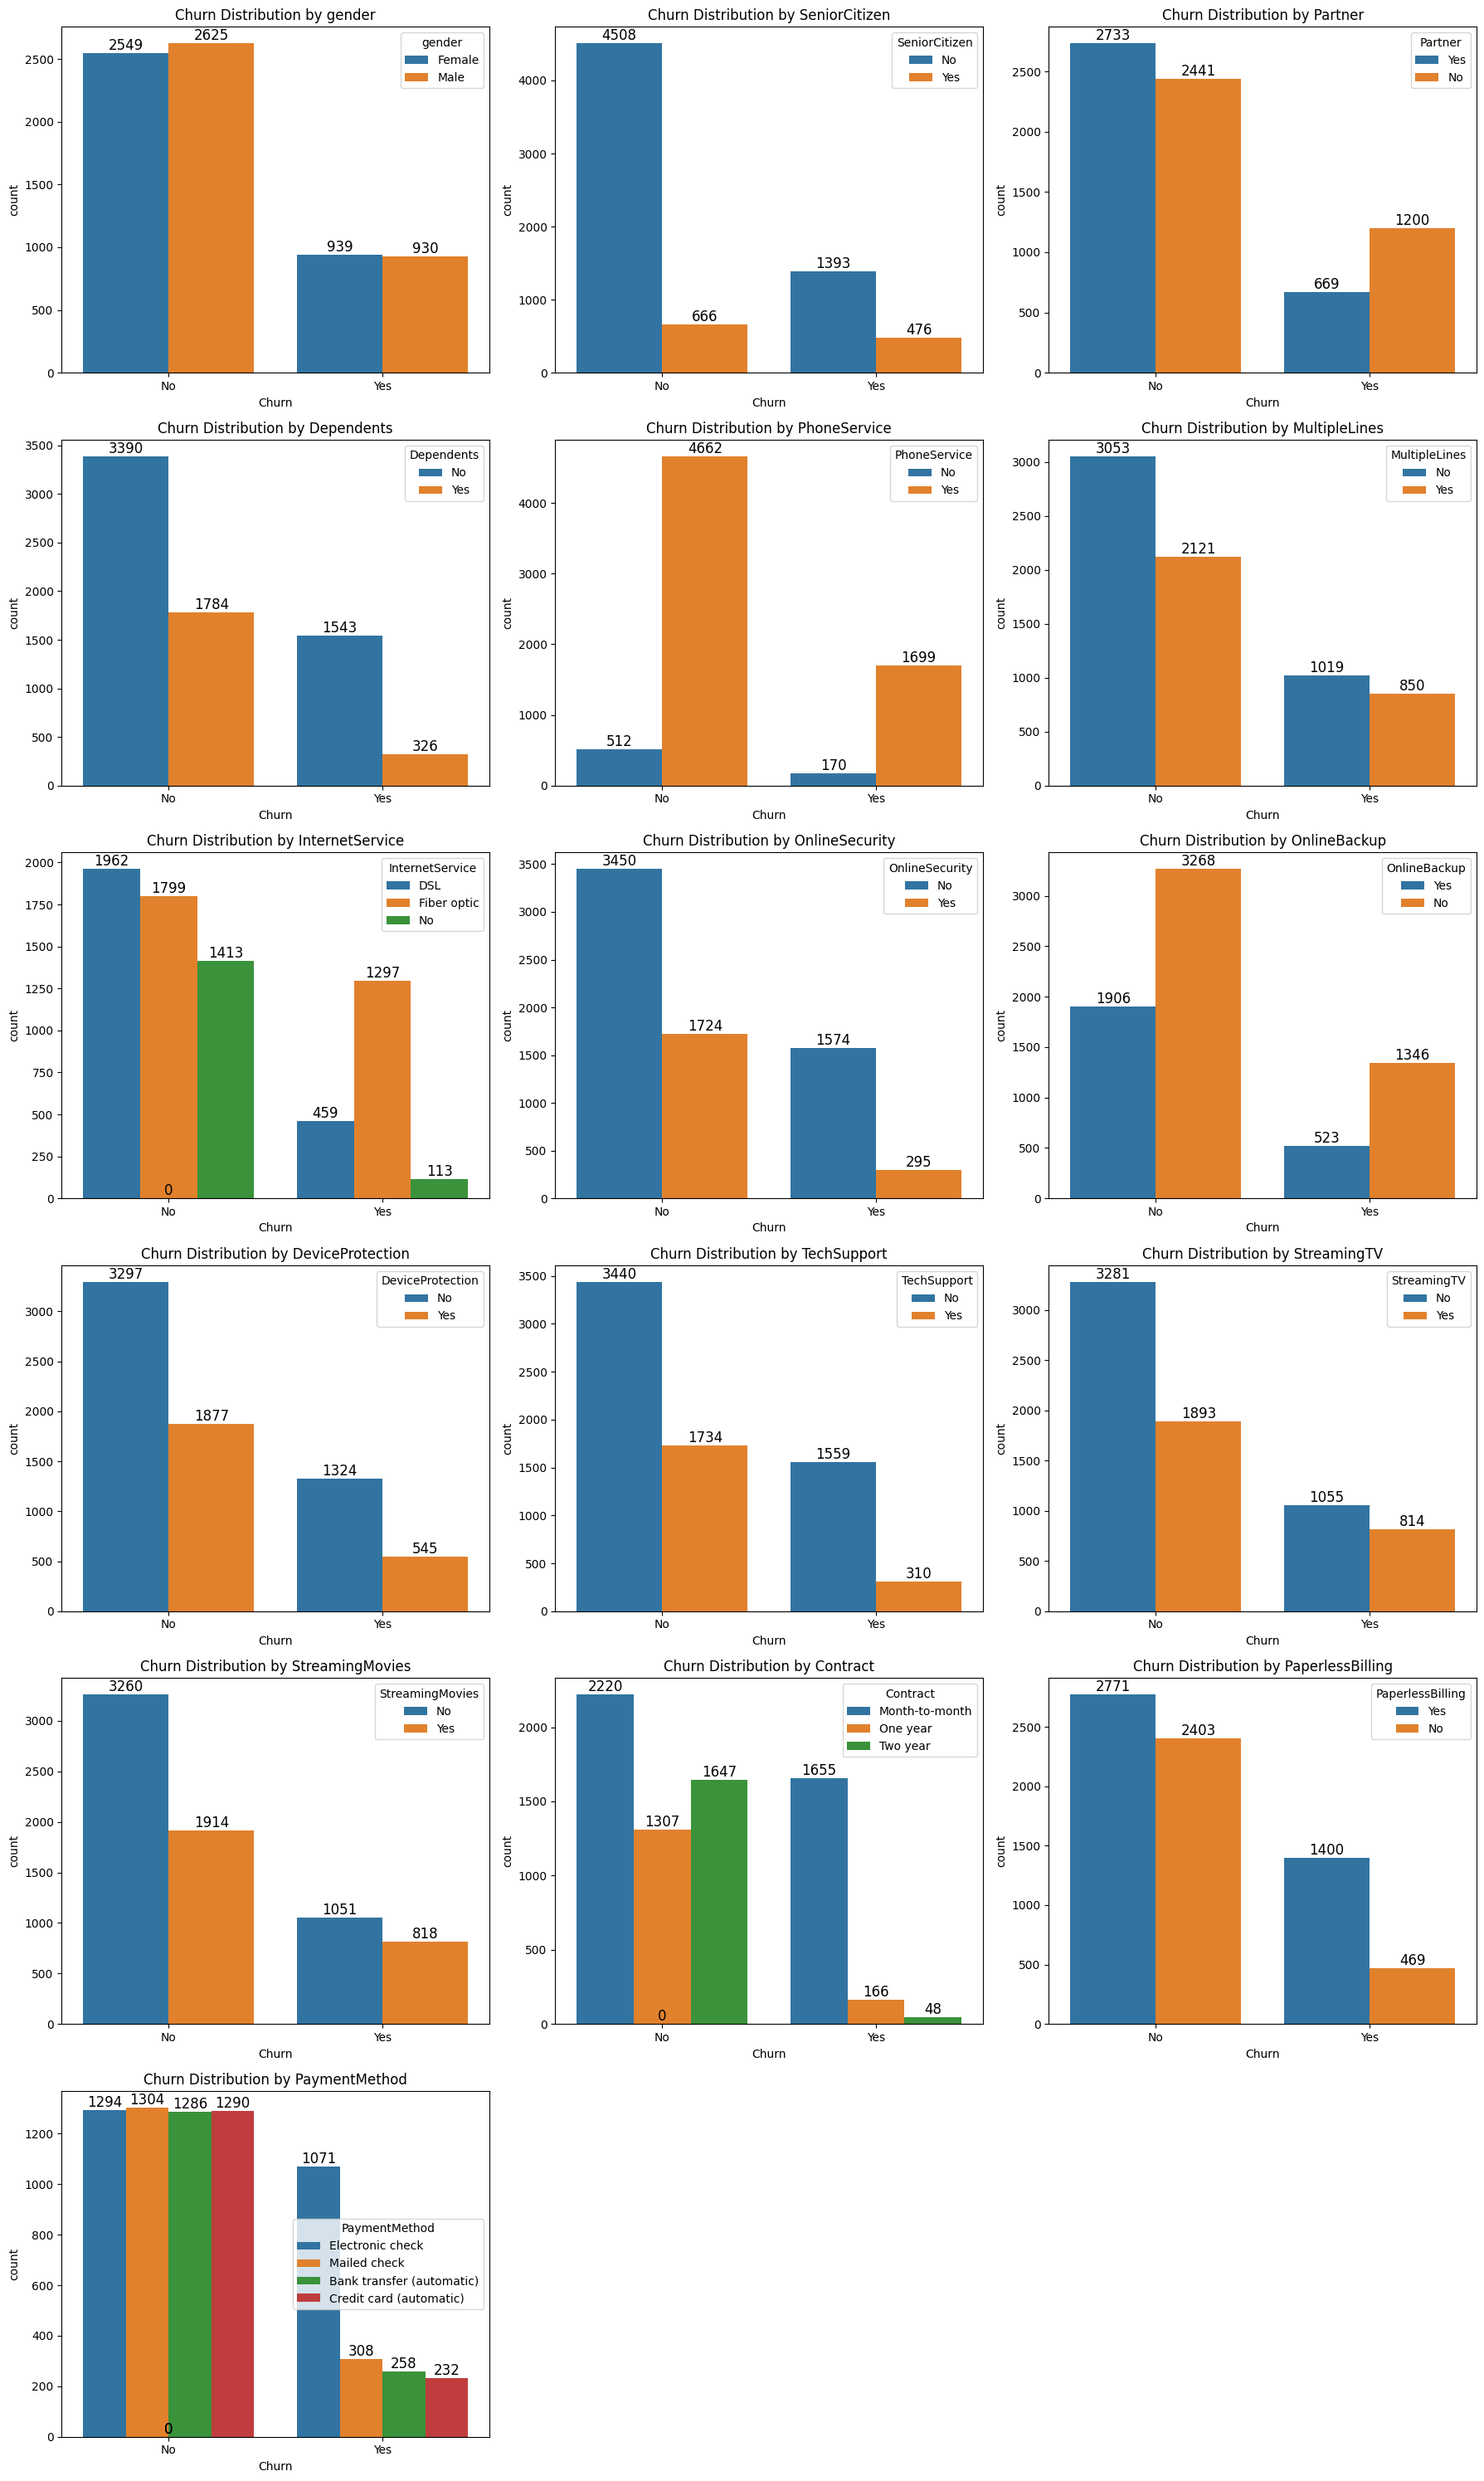

In [22]:
categorical_cols = (
    df.select_dtypes(exclude='number')
      .iloc[:, :-1]
      .columns
)

total_plots = len(categorical_cols)

n_cols = 3
n_rows = math.ceil(total_plots / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    ax = sns.countplot(
        data=df,
        x='Churn',
        hue=col,
        ax=axes[i]
    )

    axes[i].set_title(
        f'Churn Distribution by {col}'
    )

    # Add values on bars
    for p in ax.patches[:-2]:

        height = p.get_height()

        if not math.isnan(height):

            ax.annotate(
                f'{int(height)}',
                (
                    p.get_x() + p.get_width() / 2,
                    height
                ),
                ha='center',
                va='bottom',
                fontsize=12
            )

#To remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<table>

<tr>
<th>Feature</th>
<th>Insights</th>
</tr>

<tr>
<td>Gender</td>
<td>Male and female customers exhibit a similar churn distribution, indicating that gender does not appear to significantly influence customer churn.</td>
<tr>

<tr>
<td>Partner</td>
<td>Customers without a partner tend to churn approximately twice as much as customers who have a partner.</td>
<tr>

<tr>
<td>Dependents</td>
<td>Customers without dependents are more likely to churn, whereas the majority of customers with dependents tend to remain loyal.</td>
<tr>

<tr>
<td>PhoneService</td>
<td>Customers with phone service exhibit higher churn counts; however, the majority of customers with phone service still belong to the non-churn category.</td>
<tr>

<tr>
<td>InternetService</td>
<td>Customers using fiber optic internet service tend to churn more compared to customers using DSL services.</td>
<tr>

<tr>
<td>Contract</td>
<td>Customers with month-to-month contracts exhibit significantly higher churn rates, whereas customers with long-term contracts (one-year and two-year contracts) tend to be more loyal.</td>
<tr>

<tr>
<td>PaymentMethod</td>
<td>Customers using electronic check payment methods tend to churn more frequently compared to customers using other payment methods.</td>
<tr>
</table>

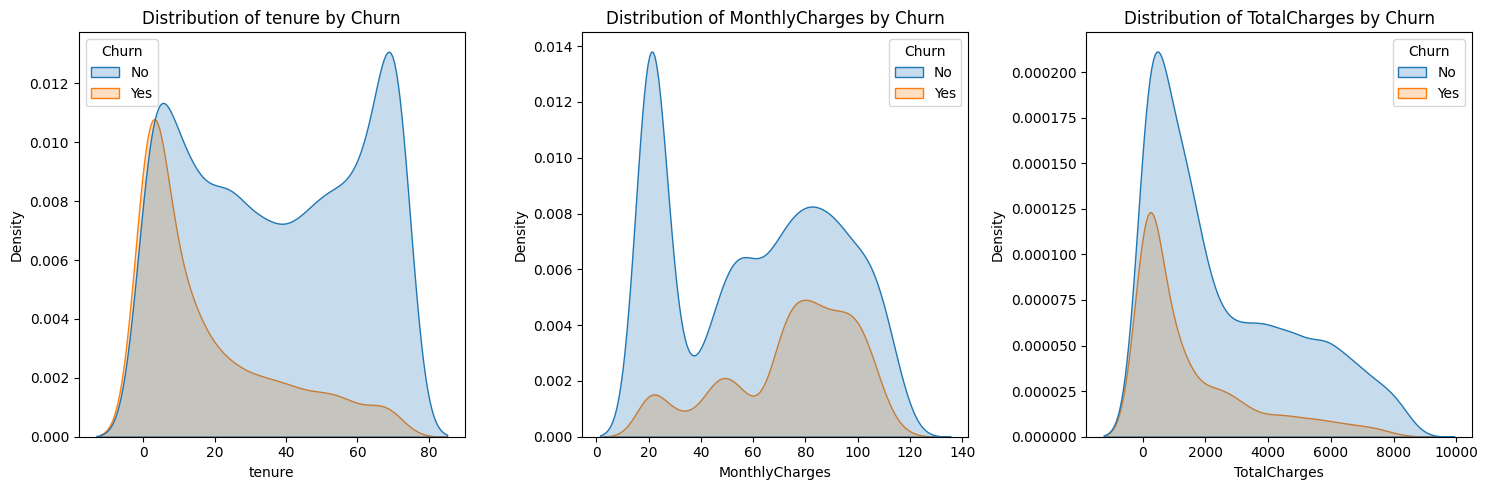

In [23]:
numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True,ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Churn')
plt.tight_layout()
plt.show()

The KDE distribution of `tenure` indicates that most customers who churn are relatively new customers, while long-term customers exhibit lower churn tendencies.

The distributions also suggest that churned customers generally tend to have lower accumulated total charges, which is expected since newer customers typically have shorter subscription durations.

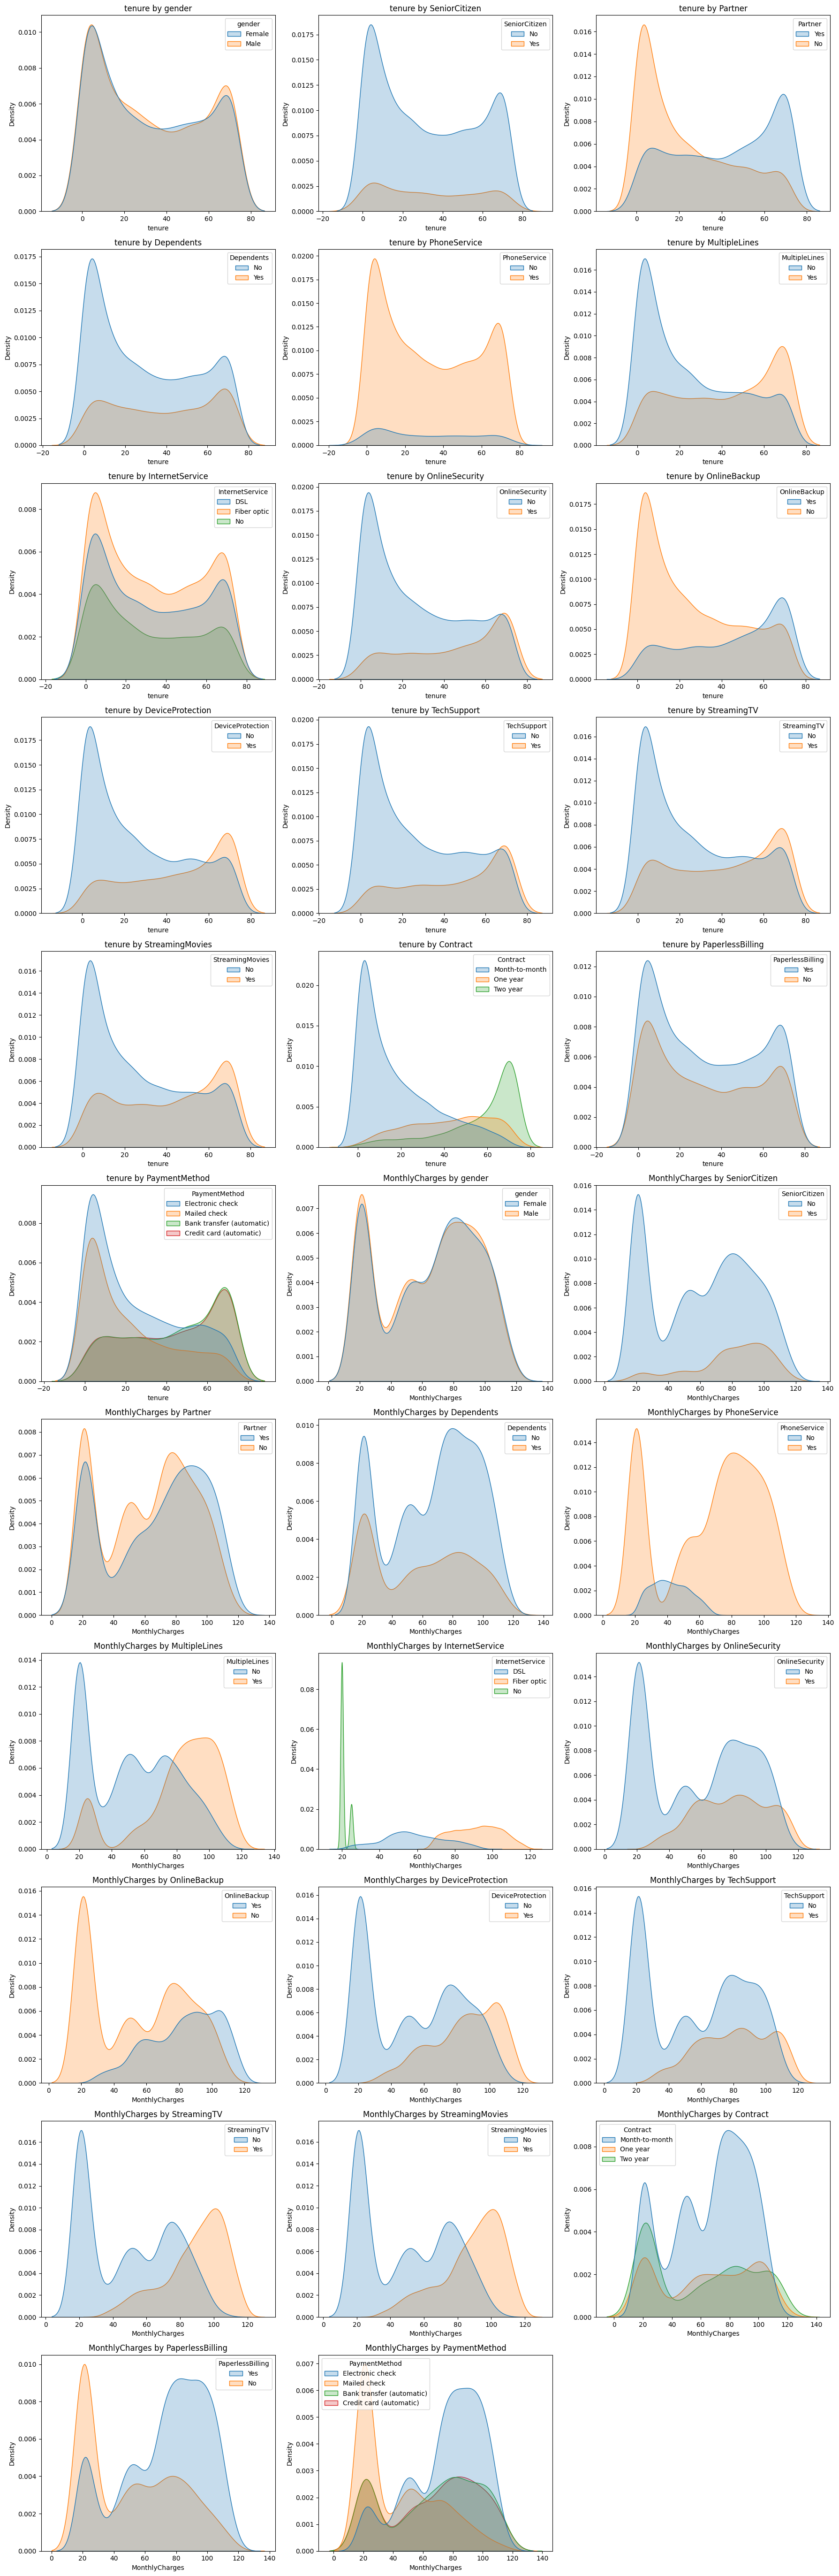

In [24]:
x_cols = ['tenure', 'MonthlyCharges']

hue_cols = (df.select_dtypes(exclude='number').iloc[:, :-1].columns)

total_plots = len(x_cols) * len(hue_cols)

n_cols = 3
n_rows = math.ceil(total_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))

axes = axes.flatten()

plot_idx = 0

for x_col in x_cols:

    for hue_col in hue_cols:
        sns.kdeplot(data=df, x=x_col, hue=hue_col, fill=True, ax=axes[plot_idx])

        axes[plot_idx].set_title(f'{x_col} by {hue_col}')

        plot_idx += 1

for j in range(plot_idx, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Customers with month-to-month contracts generally exhibit lower tenure, whereas customers with long-term contracts tend to remain subscribed for longer durations. Customers using fiber optic internet services tend to have higher monthly charges and are likely subscribed to multiple additional services.

Based on these observations, service-related features can be consolidated into a single feature representing the total number of subscribed services to reduce feature redundancy. However, the `InternetService` feature is retained separately since fiber optic users exhibit distinct customer behavior and churn patterns.

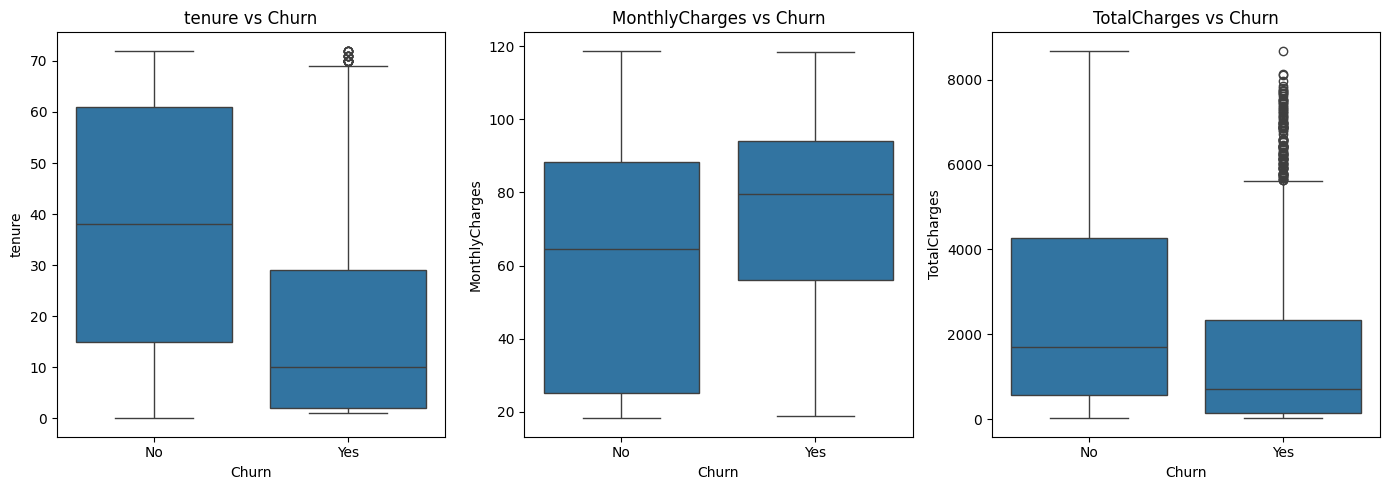

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14,5))

for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i])
    axes[i].set_title(f'{col} vs Churn' )
plt.tight_layout()
plt.show()

Customers with lower tenure appear to exhibit higher churn rates, indicating that newer customers are more likely to discontinue the service. This trend can also be observed in the `TotalCharges` distribution, where customers with lower accumulated charges tend to churn more frequently.

Although a small number of long-tenure customers also belong to the churn category, these observations appear as outliers in the boxplots because the majority of churned customers are relatively new customers. However, these outliers should not be removed from the dataset, as they may represent valuable business information regarding loyal or long-term customers who eventually decided to churn.

Therefore, the observed outliers are considered meaningful behavioral patterns rather than erroneous data points, and retaining them can help improve the model’s ability to generalize across different customer segments.

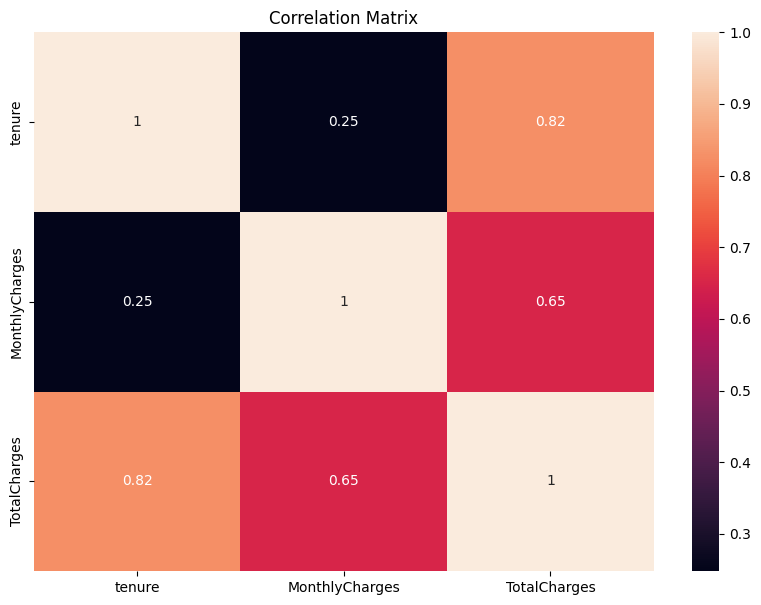

In [26]:
df_corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,7))
sns.heatmap(df_corr, annot=True)
plt.title('Correlation Matrix')
plt.show()

A strong positive correlation is observed between tenure and TotalCharges (0.82), indicating that customers with longer service durations tend to accumulate higher total charges. MonthlyCharges also shows moderate positive correlation with TotalCharges (0.65). This suggests potential multicollinearity among these features since total charges are approximately influenced by both tenure and monthly charges.

However, these features are retained since they may still provide valuable predictive information for machine learning models, particularly tree-based models such as Random Forest and XGBoost, which are generally robust to multicollinearity.

# Feature Engineering

In [27]:
df['gender'] = df['gender'].map({
    'Male': 0,
    'Female': 1
})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,No,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,0,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,0,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,0,No,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,1,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
for col in df.columns:
    if set(df[col].unique()) == {'Yes', 'No'}:
        df[col] = df[col].map({
            'Yes': 1,
            'No': 0
        })
        print(f"{col} modified")

SeniorCitizen modified
Partner modified
Dependents modified
PhoneService modified
MultipleLines modified
OnlineSecurity modified
OnlineBackup modified
DeviceProtection modified
TechSupport modified
StreamingTV modified
StreamingMovies modified
PaperlessBilling modified
Churn modified


In [29]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [30]:
service_cols = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

filtered_df = df[
    (df['InternetService'].isin(['DSL', 'Fiber optic'])) &
    (df['Contract'] == 'Month-to-month') &
    (df[service_cols] == 0).all(axis=1)
]
filtered_df[filtered_df['InternetService'] == 'Fiber optic']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


Here, it was observed that Fiber optic customers almost always use additional services. This means Fiber optic users are likely high-engagement customers and the model should retain DSL vs Fiber optic distinciton.

In [31]:
df['DSL'] = (df['InternetService'] == 'DSL').astype(int)

df['Fiber optic'] = (df['InternetService'] == 'Fiber optic').astype(int)

In [32]:
df['NumOfServices'] = df[service_cols].sum(axis=1)

In [33]:
label_encoder = LabelEncoder()
df['Contract'] = label_encoder.fit_transform(df['Contract'])

In [34]:
payment_df = pd.get_dummies(df['PaymentMethod'], dtype=int)

In [35]:
df = pd.concat([df, payment_df], axis=1)

In [36]:
df.drop(['PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'PaymentMethod'], axis=1, inplace=True)

Standardization of `MonthlyCharges` and `TotalCharges` was considered due to the difference in their numerical ranges. However, since the primary model used for this project is XGBoost, feature scaling was not applied because tree-based models are generally scale-invariant and do not rely on distance-based calculations or coefficient magnitudes for learning.

Binning of the `tenure` feature was also explored to represent different customer lifecycle stages. However, the original numerical tenure feature was retained for model training, as XGBoost can automatically determine optimal split points during training. Retaining the continuous feature preserves more granular information while still allowing tenure groups to be used separately for exploratory data analysis and business interpretation.

# Training the models

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import mlflow
import mlflow.xgboost
import optuna
import os
from dotenv import load_dotenv
load_dotenv()

MLFLOW_TRACKING_URI = os.getenv('MLFLOW_TRACKING_URI')

EXPERIMENT_NAME = os.getenv('MLFLOW_EXPERIMENT_NAME')

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1780062004971, experiment_id='1', last_update_time=1780062004971, lifecycle_stage='active', name='customer_churn_prediction', tags={}, trace_location=None, workspace='default'>

In [38]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

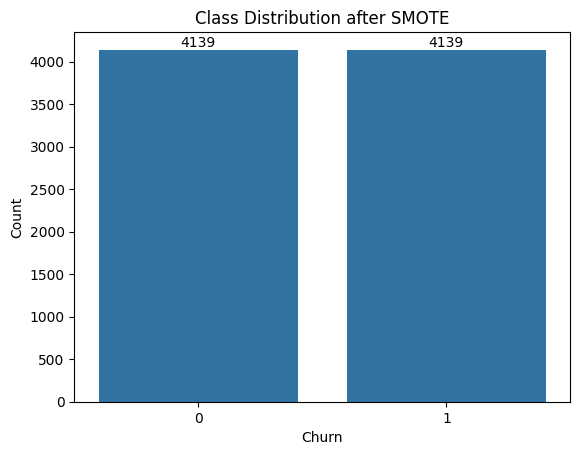

In [41]:
ax = sns.barplot(x = y_train_smote.value_counts().index, y = y_train_smote.value_counts().values)

for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')

plt.title('Class Distribution after SMOTE')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [42]:
def evaluate_model(model, X_test=X_test, y_test=y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }

1. Base model on non-oversampled data

In [ ]:
with mlflow.start_run(run_name='Base_XGBoost'):
    model = xgb.XGBClassifier(random_state=42)
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test)
    mlflow.log_params(model.get_params())
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(xgb_model=model, name='model')

🏃 View run XGBoost at: http://127.0.0.1:5000/#/experiments/1/runs/a553da658b724a43b4e2a2c8516cf3fc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2. Base model with scale_pos_weight

In [44]:
scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])

In [ ]:
with mlflow.start_run(run_name='XGBoost_scale_pos_weight'):
    model = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight ,random_state=42)
    model.fit(X_train, y_train)
    metrics = evaluate_model(model)
    mlflow.log_params(model.get_params())
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(xgb_model=model, name='model')

🏃 View run XGBoost_spw at: http://127.0.0.1:5000/#/experiments/1/runs/14e63d82b8cc40df9934f0ab70810a12
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


3. Base model on oversampled data

In [ ]:
with mlflow.start_run(run_name='XGBoost_SMOTE'):
    model = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight ,random_state=42)
    model.fit(X_train_smote, y_train_smote)
    metrics = evaluate_model(model)
    mlflow.log_params(model.get_params())
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(xgb_model=model, name='model')

🏃 View run XGBoost_oversampled_data at: http://127.0.0.1:5000/#/experiments/1/runs/4bb6736778364a618e7b9153b360b95a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


4. Optuna + scale_pos_weight

In [47]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'eval_metric': 'logloss'
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:,1]
    roc_auc = roc_auc_score(y_test, y_prob)
    return roc_auc

In [48]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2026-05-29 19:10:21,385] A new study created in memory with name: no-name-725da477-9d41-43ea-b065-556b1a4b8c12
[I 2026-05-29 19:10:21,509] Trial 0 finished with value: 0.8462631429383347 and parameters: {'n_estimators': 428, 'max_depth': 10, 'learning_rate': 0.2527027722919433, 'subsample': 0.9850556428322896, 'colsample_bytree': 0.8067508696842496, 'gamma': 2.7108404360783727, 'min_child_weight': 5, 'reg_alpha': 2.3069189520696165, 'reg_lambda': 1.887622952766717}. Best is trial 0 with value: 0.8462631429383347.
[I 2026-05-29 19:10:21,630] Trial 1 finished with value: 0.8382081686429512 and parameters: {'n_estimators': 320, 'max_depth': 5, 'learning_rate': 0.17039169282761435, 'subsample': 0.7131513704066972, 'colsample_bytree': 0.6227422586242874, 'gamma': 2.393917868043589, 'min_child_weight': 6, 'reg_alpha': 4.531002015393371, 'reg_lambda': 0.17155782776750506}. Best is trial 0 with value: 0.8462631429383347.
[I 2026-05-29 19:10:21,768] Trial 2 finished with value: 0.84480482575

In [49]:
best_params = study.best_params
best_params

{'n_estimators': 428,
 'max_depth': 10,
 'learning_rate': 0.2527027722919433,
 'subsample': 0.9850556428322896,
 'colsample_bytree': 0.8067508696842496,
 'gamma': 2.7108404360783727,
 'min_child_weight': 5,
 'reg_alpha': 2.3069189520696165,
 'reg_lambda': 1.887622952766717}

In [ ]:
with mlflow.start_run(run_name='XGBoost_Optuna'):
    model = xgb.XGBClassifier(**best_params, random_state=42, eval_metric='logloss')
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test)
    mlflow.log_params(best_params)
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(xgb_model=model, name='model')

🏃 View run Optuna_XGBoost at: http://127.0.0.1:5000/#/experiments/1/runs/219e13d656174241908c4608150a74f4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [51]:
def objective_smote(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'random_state': 42,
        'eval_metric': 'logloss'
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train_smote, y_train_smote)
    y_prob = model.predict_proba(X_test)[:,1]
    roc_auc = roc_auc_score(y_test, y_prob)
    return roc_auc

In [52]:
study_smote = optuna.create_study(direction='maximize')
study_smote.optimize(objective_smote, n_trials=30)

[I 2026-05-29 19:10:30,893] A new study created in memory with name: no-name-c67d1c73-2018-4ec1-b63c-b6906ff6691f
[I 2026-05-29 19:10:31,087] Trial 0 finished with value: 0.8315559688961223 and parameters: {'n_estimators': 236, 'max_depth': 8, 'learning_rate': 0.04024487825778414, 'subsample': 0.9580287147730474, 'colsample_bytree': 0.5905153153840835, 'gamma': 0.7940119912032323, 'min_child_weight': 3, 'reg_alpha': 1.8772137352131024, 'reg_lambda': 2.789272432235232}. Best is trial 0 with value: 0.8315559688961223.
[I 2026-05-29 19:10:31,306] Trial 1 finished with value: 0.8091567852437418 and parameters: {'n_estimators': 311, 'max_depth': 7, 'learning_rate': 0.24744230336500164, 'subsample': 0.561676562677706, 'colsample_bytree': 0.5495296819753317, 'gamma': 0.5834623319979593, 'min_child_weight': 3, 'reg_alpha': 1.674958096395593, 'reg_lambda': 0.732485671766247}. Best is trial 0 with value: 0.8315559688961223.
[I 2026-05-29 19:10:31,450] Trial 2 finished with value: 0.8328515332351

In [53]:
best_params_smote = study_smote.best_params
best_params_smote

{'n_estimators': 395,
 'max_depth': 6,
 'learning_rate': 0.15430798894704884,
 'subsample': 0.6723611516323328,
 'colsample_bytree': 0.8554859655428976,
 'gamma': 3.872277919397674,
 'min_child_weight': 10,
 'reg_alpha': 3.6797024256531645,
 'reg_lambda': 1.1045172753134165}

In [ ]:
with mlflow.start_run(run_name='XGBoost_Optuna_SMOTE'):
    model = xgb.XGBClassifier(**best_params_smote, random_state=42, eval_metric='logloss')
    model.fit(X_train_smote, y_train_smote)
    metrics = evaluate_model(model, X_test, y_test)
    mlflow.log_params(best_params_smote)
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(xgb_model=model, name='model')

🏃 View run Optuna_XGBoost_oversampled_data at: http://127.0.0.1:5000/#/experiments/1/runs/ed00432414914162a2e088abd700e63b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


The `XGBoost_Optuna_SMOTE` model demonstrated the best overall performance among all the evaluated models. Although the `XGBoost_Optuna` model achieved slightly higher accuracy and ROC-AUC score, its recall was comparatively lower, indicating that it failed to identify a larger number of churn customers. In customer churn prediction, recall is a critical metric since incorrectly classifying potential churn customers as non-churn customers may result in customer loss and reduced business retention.

The `XGBoost_Optuna_SMOTE` model achieved the highest F1-score while maintaining a strong balance between precision and recall. Additionally, the model achieved a high ROC-AUC score, indicating strong capability in distinguishing churn and non-churn customers. The use of SMOTE helped address class imbalance by improving the model’s ability to learn minority class patterns, while Optuna hyperparameter optimization further enhanced the model’s predictive performance.

In [55]:
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

In [56]:
filtered_runs = runs_df[runs_df['metrics.recall'] > 0.60]
best_run = filtered_runs.sort_values(by=['metrics.f1_score', 'metrics.roc_auc'], ascending=False).iloc[0]

In [57]:
best_run_id = best_run['run_id']
best_run_name = best_run['tags.mlflow.runName']
print('Best Run Name:', best_run_name)

Best Run Name: Optuna_XGBoost_oversampled_data


In [58]:
best_model = mlflow.xgboost.load_model(f'runs:/{best_run_id}/model')

In [59]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [61]:
print(f'Accuracy: {round(accuracy_score(y_test, y_pred), 2)}')
print(f'Precision: {round(precision_score(y_test, y_pred), 2)}')
print(f'Recall: {round(recall_score(y_test, y_pred), 2)}')
print(f'F1-score: {round(f1_score(y_test, y_pred), 2)}')
print(f'ROC-AUC: {round(roc_auc_score(y_test, y_prob), 2)}')

Accuracy: 0.78
Precision: 0.57
Recall: 0.66
F1-score: 0.61
ROC-AUC: 0.83


In [64]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.66      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



<Figure size 1000x700 with 0 Axes>

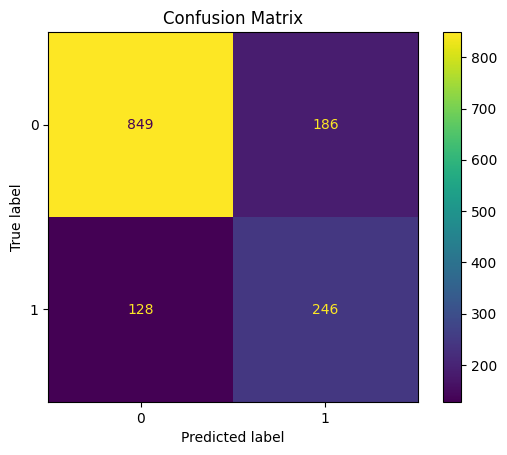

In [66]:
plt.figure(figsize=(10,7))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title('Confusion Matrix')
plt.show()

<Figure size 1000x700 with 0 Axes>

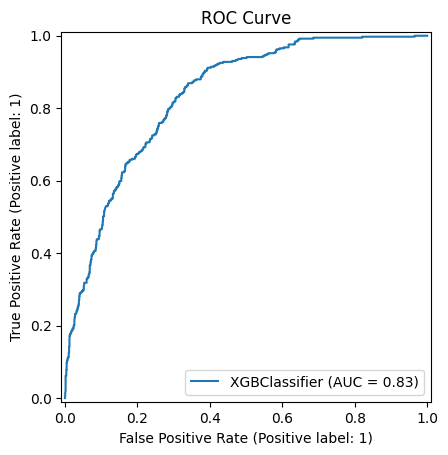

In [67]:
plt.figure(figsize=(10,7))
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title('ROC Curve')
plt.show()

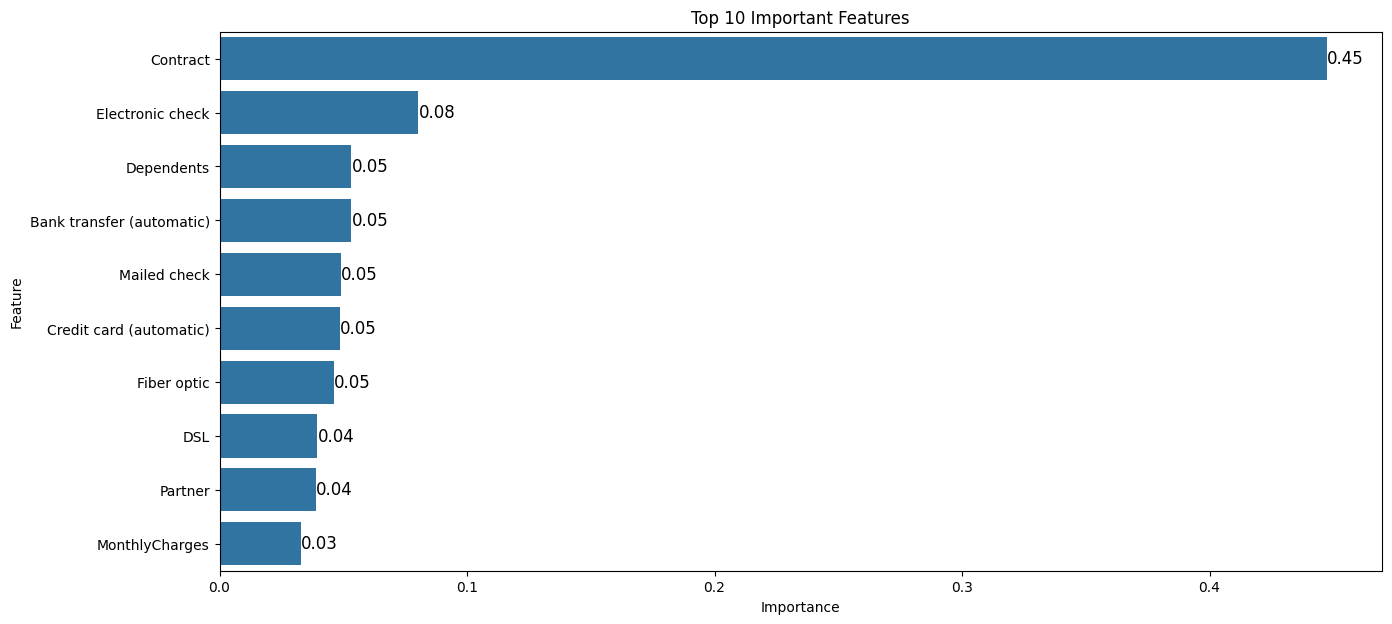

In [81]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(15,7))
ax = sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
for p in ax.patches:
    ax.annotate(
        round(p.get_width(), 2), (p.get_width(), p.get_y() + p.get_height() / 2), ha='left', va='center', fontsize=12
    )
plt.title('Top 10 Important Features')
plt.show()